device: cuda
X_all: torch.Size([60000, 1, 28, 28])
Y_all: torch.Size([60000])
Model A: torch.Size([25000, 1, 28, 28])
Model B: torch.Size([25000, 1, 28, 28])
Eval   : torch.Size([1000, 1, 28, 28])
Models initialized identically.
Epoch   1 | A loss: 0.3691 | B loss: 0.3691 | Weight L2: 3.9437
Epoch   2 | A loss: 0.3134 | B loss: 0.3134 | Weight L2: 6.0050
Epoch   3 | A loss: 0.2131 | B loss: 0.2131 | Weight L2: 8.0143
Epoch   4 | A loss: 0.1311 | B loss: 0.1311 | Weight L2: 9.8750
Epoch   5 | A loss: 0.1331 | B loss: 0.1331 | Weight L2: 11.4757
Epoch   6 | A loss: 0.1690 | B loss: 0.1690 | Weight L2: 12.8922
Epoch   7 | A loss: 0.1166 | B loss: 0.1166 | Weight L2: 14.1679
Epoch   8 | A loss: 0.0784 | B loss: 0.0784 | Weight L2: 15.3514
Epoch   9 | A loss: 0.0721 | B loss: 0.0721 | Weight L2: 16.4788
Epoch  10 | A loss: 0.0496 | B loss: 0.0496 | Weight L2: 17.4940
Epoch  11 | A loss: 0.0746 | B loss: 0.0746 | Weight L2: 18.4590
Epoch  12 | A loss: 0.0680 | B loss: 0.0680 | Weight L2: 19.

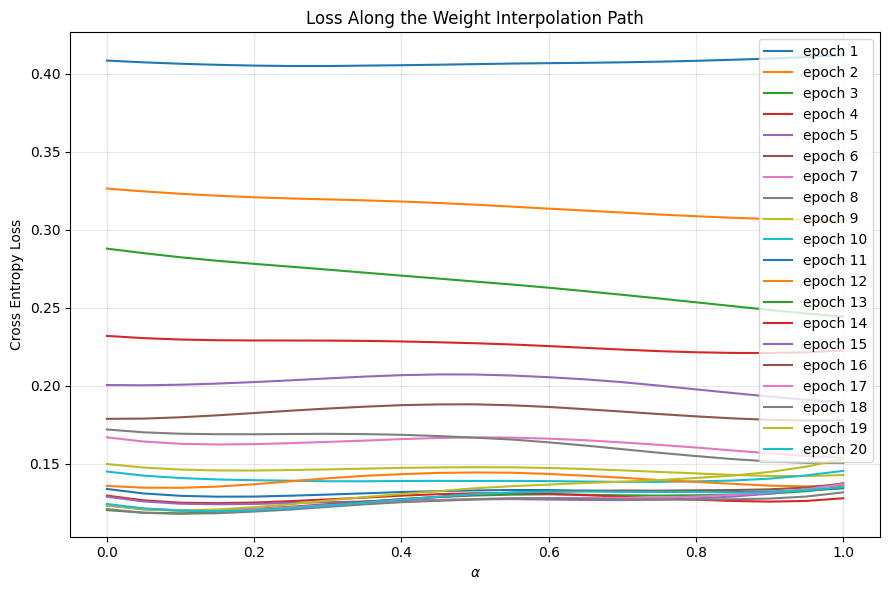

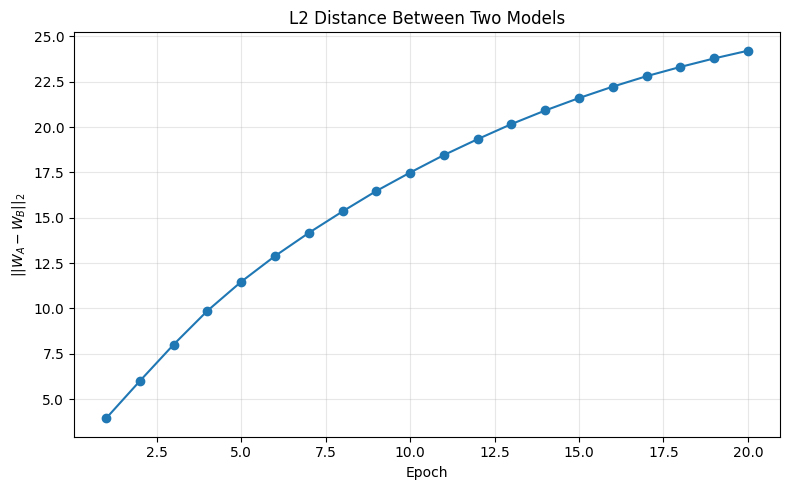


Final interpolation losses
----------------------------------------
alpha=0.00 : loss=0.124312
alpha=0.05 : loss=0.121507
alpha=0.10 : loss=0.120065
alpha=0.15 : loss=0.119708
alpha=0.20 : loss=0.120239
alpha=0.25 : loss=0.121684
alpha=0.30 : loss=0.123267
alpha=0.35 : loss=0.125222
alpha=0.40 : loss=0.127168
alpha=0.45 : loss=0.128989
alpha=0.50 : loss=0.130572
alpha=0.55 : loss=0.131727
alpha=0.60 : loss=0.132151
alpha=0.65 : loss=0.132283
alpha=0.70 : loss=0.132063
alpha=0.75 : loss=0.132039
alpha=0.80 : loss=0.132019
alpha=0.85 : loss=0.131701
alpha=0.90 : loss=0.131798
alpha=0.95 : loss=0.133088
alpha=1.00 : loss=0.135200

Final weight L2 distance: 24.211206


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torchvision import datasets, transforms


# ============================================================
# 1. 설정
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

EPOCHS = 20
BATCH_SIZE = 512
LR = 1e-3

N_TRAIN_PER_MODEL = 25_000
N_EVAL = 1_000

# weight interpolation
N_ALPHA = 21
alphas = torch.linspace(0.0, 1.0, N_ALPHA, device=device)

print("device:", device)


# ============================================================
# 2. MNIST
# ============================================================
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# MNIST 전체를 GPU에 올림
# [60000, 1, 28, 28]
X_all = train_dataset.data.float().div(255.0).unsqueeze(1).to(device)
Y_all = train_dataset.targets.to(device)

print("X_all:", X_all.shape)
print("Y_all:", Y_all.shape)


# ============================================================
# 3. 두 모델에 사용할 서로 다른 25k 데이터
# ============================================================
g = torch.Generator(device="cpu")
g.manual_seed(SEED)

perm = torch.randperm(len(X_all), generator=g)

idx_A = perm[:N_TRAIN_PER_MODEL]
idx_B = perm[N_TRAIN_PER_MODEL:2 * N_TRAIN_PER_MODEL]

# 평가용 1000개
idx_eval = perm[2 * N_TRAIN_PER_MODEL:
                2 * N_TRAIN_PER_MODEL + N_EVAL]

X_A = X_all[idx_A]
Y_A = Y_all[idx_A]

X_B = X_all[idx_B]
Y_B = Y_all[idx_B]

X_eval = X_all[idx_eval]
Y_eval = Y_all[idx_eval]

print("Model A:", X_A.shape)
print("Model B:", X_B.shape)
print("Eval   :", X_eval.shape)


# ============================================================
# 4. 모델
# ============================================================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# 5. 같은 initialization에서 두 모델 생성
# ============================================================
torch.manual_seed(SEED)

model_A = MLP().to(device)

# A의 정확히 같은 weight를 B에 복사
model_B = MLP().to(device)
model_B.load_state_dict(model_A.state_dict())

print("Models initialized identically.")


# ============================================================
# 6. Optimizer
# ============================================================
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=LR)
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=LR)


# ============================================================
# 7. Weight L2 distance
# ============================================================
@torch.no_grad()
def weight_l2_distance(model1, model2):
    sq_sum = torch.zeros((), device=device)

    for p1, p2 in zip(model1.parameters(), model2.parameters()):
        sq_sum += torch.sum((p1 - p2) ** 2)

    return torch.sqrt(sq_sum)


# ============================================================
# 8. interpolation loss
# ============================================================
@torch.no_grad()
def interpolation_losses(model_A, model_B, X, Y, alphas):
    """
    W(alpha) = (1-alpha) W_A + alpha W_B

    각 alpha에 해당하는 interpolated model의
    loss를 계산한다.
    """

    model_A.eval()
    model_B.eval()

    # parameter들을 미리 가져옴
    params_A = [p for p in model_A.parameters()]
    params_B = [p for p in model_B.parameters()]

    losses = []

    for alpha in alphas:

        # 새로운 모델을 만들지 않고
        # functional_call을 이용하는 방법도 있지만,
        # 여기서는 명확성을 위해 임시 모델 사용
        model_interp = MLP().to(device)

        with torch.no_grad():
            for p_interp, pA, pB in zip(
                model_interp.parameters(),
                params_A,
                params_B
            ):
                p_interp.copy_(
                    (1.0 - alpha) * pA + alpha * pB
                )

        logits = model_interp(X)
        loss = F.cross_entropy(logits, Y)

        losses.append(loss.item())

        del model_interp

    return losses


# ============================================================
# 9. 학습
# ============================================================
interp_history = []
distance_history = []

for epoch in range(1, EPOCHS + 1):

    model_A.train()
    model_B.train()

    # GPU에 이미 데이터가 있으므로 DataLoader 없이
    # random permutation만 GPU에서 수행
    perm_A = torch.randperm(
        N_TRAIN_PER_MODEL,
        device=device
    )

    perm_B = torch.randperm(
        N_TRAIN_PER_MODEL,
        device=device
    )

    # --------------------------------------------------------
    # Model A
    # --------------------------------------------------------
    for start in range(0, N_TRAIN_PER_MODEL, BATCH_SIZE):

        batch_idx = perm_A[start:start + BATCH_SIZE]

        xb = X_A[batch_idx]
        yb = Y_A[batch_idx]

        optimizer_A.zero_grad(set_to_none=True)

        logits = model_A(xb)
        loss = F.cross_entropy(logits, yb)

        loss.backward()
        optimizer_A.step()

    # --------------------------------------------------------
    # Model B
    # --------------------------------------------------------
    for start in range(0, N_TRAIN_PER_MODEL, BATCH_SIZE):

        batch_idx = perm_B[start:start + BATCH_SIZE]

        xb = X_B[batch_idx]
        yb = Y_B[batch_idx]

        optimizer_B.zero_grad(set_to_none=True)

        logits = model_B(xb)
        loss = F.cross_entropy(logits, yb)

        loss.backward()
        optimizer_B.step()

    # --------------------------------------------------------
    # Weight L2 distance
    # --------------------------------------------------------
    distance = weight_l2_distance(model_A, model_B).item()
    distance_history.append(distance)

    # --------------------------------------------------------
    # 1000개 sample에서 interpolation loss
    # --------------------------------------------------------
    losses = interpolation_losses(
        model_A,
        model_B,
        X_eval,
        Y_eval,
        alphas
    )

    interp_history.append(losses)

    print(
        f"Epoch {epoch:3d} | "
        f"A loss: {loss.item():.4f} | "
        f"B loss: {loss.item():.4f} | "
        f"Weight L2: {distance:.4f}"
    )


# ============================================================
# 10. 결과를 Tensor로 변환
# ============================================================
interp_history = torch.tensor(interp_history)

# shape:
# [epoch, alpha]


# ============================================================
# 11. Epoch별 interpolation loss curve
# ============================================================
plt.figure(figsize=(9, 6))

for epoch in range(EPOCHS):
    plt.plot(
        alphas.cpu().numpy(),
        interp_history[epoch].numpy(),
        label=f"epoch {epoch + 1}"
    )

plt.xlabel(r"$\alpha$")
plt.ylabel("Cross Entropy Loss")
plt.title("Loss Along the Weight Interpolation Path")
plt.grid(True, alpha=0.3)

# epoch가 많으면 legend가 너무 커지므로 필요하면 주석 처리
if EPOCHS <= 20:
    plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 12. Weight L2 distance
# ============================================================
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    distance_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel(r"$||W_A - W_B||_2$")
plt.title("L2 Distance Between Two Models")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 13. 최종 interpolation loss 출력
# ============================================================
print("\nFinal interpolation losses")
print("-" * 40)

for alpha, loss in zip(
    alphas.cpu().numpy(),
    interp_history[-1].numpy()
):
    print(f"alpha={alpha:.2f} : loss={loss:.6f}")

print()
print(f"Final weight L2 distance: {distance_history[-1]:.6f}")

device: cuda


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset({
    features: ['img', 'label'],
    num_rows: 50000
})
Dataset({
    features: ['img', 'label'],
    num_rows: 10000
})
Converting CIFAR-10 to tensors...
CPU tensor: torch.Size([50000, 3, 32, 32])
GPU tensor: torch.Size([50000, 3, 32, 32])

Model A: torch.Size([25000, 3, 32, 32])
Model B: torch.Size([25000, 3, 32, 32])
Eval   : torch.Size([1000, 3, 32, 32])
Epoch   1 | A: 2.0444 | B: 2.0171 | L2: 9.0572
Epoch   2 | A: 1.7343 | B: 1.7722 | L2: 14.4809
Epoch   3 | A: 1.5688 | B: 1.5972 | L2: 18.9871
Epoch   4 | A: 1.4340 | B: 1.4779 | L2: 22.5697
Epoch   5 | A: 1.3461 | B: 1.3779 | L2: 25.2958
Epoch   6 | A: 1.2511 | B: 1.2941 | L2: 27.6602
Epoch   7 | A: 1.1903 | B: 1.2156 | L2: 29.7113
Epoch   8 | A: 1.1228 | B: 1.1610 | L2: 31.5141
Epoch   9 | A: 1.0614 | B: 1.0909 | L2: 33.0489
Epoch  10 | A: 1.0158 | B: 1.0617 | L2: 34.4543
Epoch  11 | A: 0.9624 | B: 1.0209 | L2: 35.7298
Epoch  12 | A: 0.9264 | B: 0.9913 | L2: 36.8841
Epoch  13 | A: 0.9098 | B: 0.9663 | L2: 38.0238
Epoch  

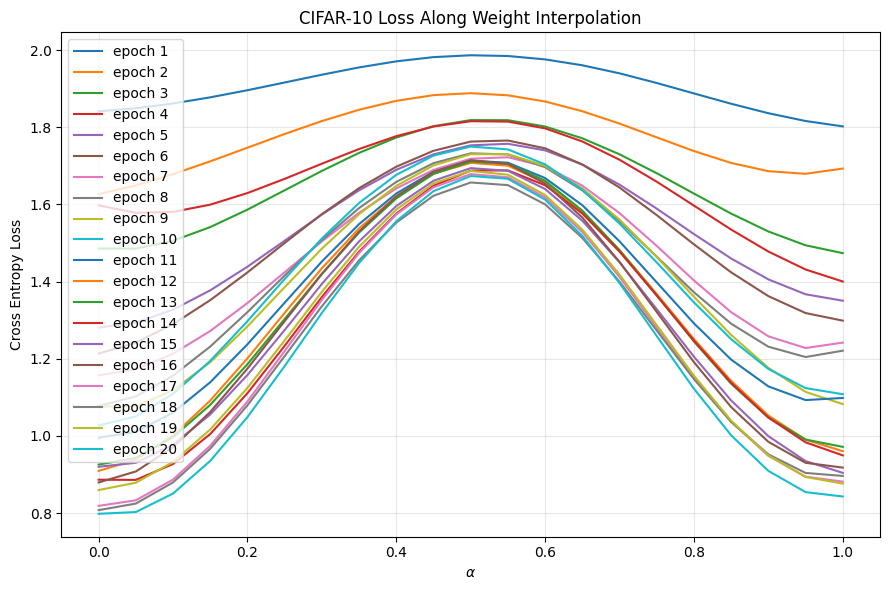

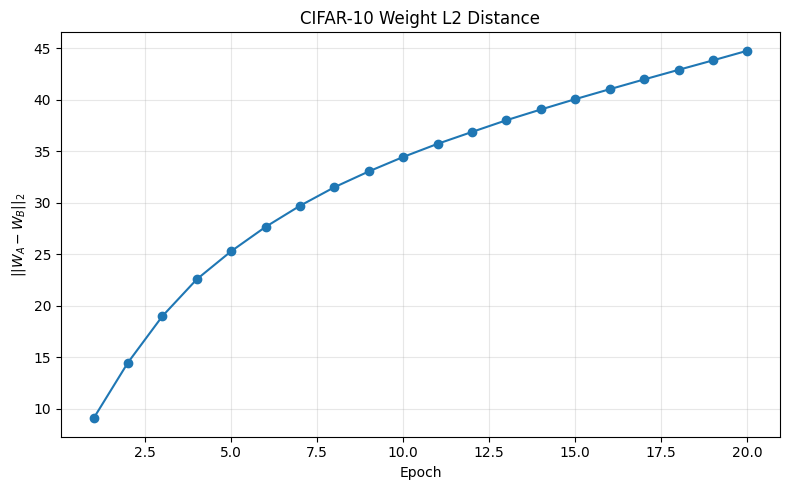

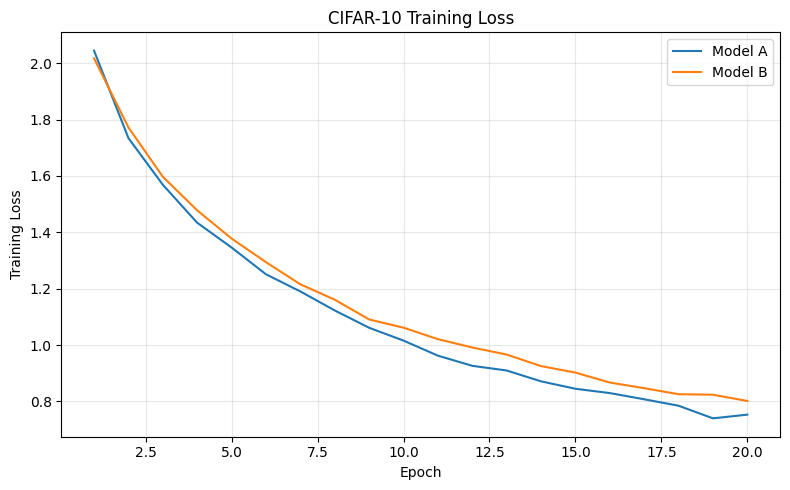


Final interpolation loss
alpha = 0.00 | loss = 0.798391
alpha = 0.05 | loss = 0.802922
alpha = 0.10 | loss = 0.850874
alpha = 0.15 | loss = 0.935530
alpha = 0.20 | loss = 1.048975
alpha = 0.25 | loss = 1.181228
alpha = 0.30 | loss = 1.318926
alpha = 0.35 | loss = 1.448125
alpha = 0.40 | loss = 1.556564
alpha = 0.45 | loss = 1.634539
alpha = 0.50 | loss = 1.673679
alpha = 0.55 | loss = 1.666507
alpha = 0.60 | loss = 1.612619
alpha = 0.65 | loss = 1.518628
alpha = 0.70 | loss = 1.396313
alpha = 0.75 | loss = 1.259003
alpha = 0.80 | loss = 1.122384
alpha = 0.85 | loss = 1.001665
alpha = 0.90 | loss = 0.909560
alpha = 0.95 | loss = 0.854553
alpha = 1.00 | loss = 0.843190

Final L2 distance = 44.774487


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset


# ============================================================
# 1. Config
# ============================================================
SEED = 42

EPOCHS = 20
BATCH_SIZE = 256
LR = 1e-3

N_TRAIN_PER_MODEL = 25_000
N_EVAL = 1_000

N_ALPHA = 21

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. Load CIFAR-10 from Hugging Face
# ============================================================
dataset = load_dataset(
    "uoft-cs/cifar10",
    "plain_text"
)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)


# ============================================================
# 3. Convert HF images -> Tensor
# ============================================================
def dataset_to_tensor(ds):
    """
    HF CIFAR-10 dataset
    image: PIL.Image
    label: int

    ->

    X: [N, 3, 32, 32]
    Y: [N]
    """

    images = []
    labels = []

    for sample in ds:
        # PIL -> numpy -> torch
        x = torch.from_numpy(
            __import__("numpy").array(sample["img"])
        )

        # [H, W, C] -> [C, H, W]
        x = x.permute(2, 0, 1)

        images.append(x)
        labels.append(sample["label"])

    X = torch.stack(images).float() / 255.0
    Y = torch.tensor(labels, dtype=torch.long)

    return X, Y


print("Converting CIFAR-10 to tensors...")

X_cpu, Y_cpu = dataset_to_tensor(train_dataset)

print("CPU tensor:", X_cpu.shape)


# ============================================================
# 4. GPU에 전체 train set 올리기
# ============================================================
X_all = X_cpu.to(device)
Y_all = Y_cpu.to(device)

del X_cpu
del Y_cpu

print("GPU tensor:", X_all.shape)


# ============================================================
# 5. Dataset split
#
# 50000 train
#
# 25000 -> Model A
# 25000 -> Model B
#
# evaluation 1000은 test set에서 가져옴
# ============================================================
g = torch.Generator(device="cpu")
g.manual_seed(SEED)

perm = torch.randperm(
    len(X_all),
    generator=g
)

idx_A = perm[:N_TRAIN_PER_MODEL]
idx_B = perm[
    N_TRAIN_PER_MODEL:
    2 * N_TRAIN_PER_MODEL
]

X_A = X_all[idx_A]
Y_A = Y_all[idx_A]

X_B = X_all[idx_B]
Y_B = Y_all[idx_B]


# ============================================================
# 6. Test set
#
# interpolation loss를 측정할 1000개
# ============================================================
X_eval_cpu, Y_eval_cpu = dataset_to_tensor(test_dataset)

X_eval = X_eval_cpu[:N_EVAL].to(device)
Y_eval = Y_eval_cpu[:N_EVAL].to(device)

del X_eval_cpu
del Y_eval_cpu

print()
print("Model A:", X_A.shape)
print("Model B:", X_B.shape)
print("Eval   :", X_eval.shape)


# ============================================================
# 7. CIFAR-10 CNN
# ============================================================
class CIFARNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # 32x32
            nn.Conv2d(
                3, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                64, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 16x16

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                128, 128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 8x8

            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Linear(256, 10)


    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        return self.classifier(x)


# ============================================================
# 8. SAME initialization
# ============================================================
torch.manual_seed(SEED)

model_A = CIFARNet().to(device)

model_B = CIFARNet().to(device)

# 정확히 동일한 initialization
model_B.load_state_dict(
    model_A.state_dict()
)


# ============================================================
# 9. Optimizers
# ============================================================
optimizer_A = torch.optim.Adam(
    model_A.parameters(),
    lr=LR
)

optimizer_B = torch.optim.Adam(
    model_B.parameters(),
    lr=LR
)


# ============================================================
# 10. Weight L2 distance
# ============================================================
@torch.no_grad()
def weight_l2_distance(model1, model2):

    sq_sum = torch.zeros(
        (),
        device=device
    )

    for p1, p2 in zip(
        model1.parameters(),
        model2.parameters()
    ):

        sq_sum += torch.sum(
            (p1 - p2) ** 2
        )

    return torch.sqrt(sq_sum)


# ============================================================
# 11. Interpolation loss
# ============================================================
@torch.no_grad()
def interpolation_losses(
    model_A,
    model_B,
    X,
    Y,
    alphas
):

    model_A.eval()
    model_B.eval()

    losses = []

    # --------------------------------------------------------
    # 현재 parameter를 저장
    # --------------------------------------------------------
    params_A = [
        p.detach()
        for p in model_A.parameters()
    ]

    params_B = [
        p.detach()
        for p in model_B.parameters()
    ]

    # --------------------------------------------------------
    # alpha별로 interpolated model 생성
    # --------------------------------------------------------
    for alpha in alphas:

        model_interp = CIFARNet().to(device)

        with torch.no_grad():

            for p_interp, p_A, p_B in zip(
                model_interp.parameters(),
                params_A,
                params_B
            ):

                p_interp.copy_(
                    (1.0 - alpha) * p_A
                    + alpha * p_B
                )

        logits = model_interp(X)

        loss = F.cross_entropy(
            logits,
            Y
        )

        losses.append(
            loss.item()
        )

        del model_interp

    return losses


# ============================================================
# 12. Alpha
# ============================================================
alphas = torch.linspace(
    0.0,
    1.0,
    N_ALPHA,
    device=device
)


# ============================================================
# 13. Training
# ============================================================
interp_history = []
distance_history = []

loss_A_history = []
loss_B_history = []


for epoch in range(1, EPOCHS + 1):

    model_A.train()
    model_B.train()


    # ========================================================
    # Model A
    # ========================================================
    perm_A = torch.randperm(
        N_TRAIN_PER_MODEL,
        device=device
    )

    total_loss_A = 0.0
    n_A = 0

    for start in range(
        0,
        N_TRAIN_PER_MODEL,
        BATCH_SIZE
    ):

        batch_idx = perm_A[
            start:
            start + BATCH_SIZE
        ]

        xb = X_A[batch_idx]
        yb = Y_A[batch_idx]

        optimizer_A.zero_grad(
            set_to_none=True
        )

        logits = model_A(xb)

        loss = F.cross_entropy(
            logits,
            yb
        )

        loss.backward()

        optimizer_A.step()

        total_loss_A += (
            loss.item() * len(batch_idx)
        )

        n_A += len(batch_idx)


    # ========================================================
    # Model B
    # ========================================================
    perm_B = torch.randperm(
        N_TRAIN_PER_MODEL,
        device=device
    )

    total_loss_B = 0.0
    n_B = 0

    for start in range(
        0,
        N_TRAIN_PER_MODEL,
        BATCH_SIZE
    ):

        batch_idx = perm_B[
            start:
            start + BATCH_SIZE
        ]

        xb = X_B[batch_idx]
        yb = Y_B[batch_idx]

        optimizer_B.zero_grad(
            set_to_none=True
        )

        logits = model_B(xb)

        loss = F.cross_entropy(
            logits,
            yb
        )

        loss.backward()

        optimizer_B.step()

        total_loss_B += (
            loss.item() * len(batch_idx)
        )

        n_B += len(batch_idx)


    avg_loss_A = total_loss_A / n_A
    avg_loss_B = total_loss_B / n_B

    loss_A_history.append(avg_loss_A)
    loss_B_history.append(avg_loss_B)


    # ========================================================
    # Weight L2 distance
    # ========================================================
    distance = weight_l2_distance(
        model_A,
        model_B
    ).item()

    distance_history.append(distance)


    # ========================================================
    # Interpolation loss
    #
    # test set의 1000개 sample
    # ========================================================
    losses = interpolation_losses(
        model_A,
        model_B,
        X_eval,
        Y_eval,
        alphas
    )

    interp_history.append(losses)


    print(
        f"Epoch {epoch:3d} | "
        f"A: {avg_loss_A:.4f} | "
        f"B: {avg_loss_B:.4f} | "
        f"L2: {distance:.4f}"
    )


# ============================================================
# 14. Tensor 변환
# ============================================================
interp_history = torch.tensor(
    interp_history
)

alphas_cpu = alphas.cpu().numpy()


# ============================================================
# 15. Interpolation curve
# ============================================================
plt.figure(figsize=(9, 6))

for epoch in range(EPOCHS):

    plt.plot(
        alphas_cpu,
        interp_history[epoch].numpy(),
        label=f"epoch {epoch + 1}"
    )

plt.xlabel(r"$\alpha$")
plt.ylabel("Cross Entropy Loss")

plt.title(
    "CIFAR-10 Loss Along Weight Interpolation"
)

plt.grid(
    True,
    alpha=0.3
)

if EPOCHS <= 20:
    plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 16. L2 distance
# ============================================================
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    distance_history,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel(
    r"$||W_A-W_B||_2$"
)

plt.title(
    "CIFAR-10 Weight L2 Distance"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. Training loss
# ============================================================
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    loss_A_history,
    label="Model A"
)

plt.plot(
    range(1, EPOCHS + 1),
    loss_B_history,
    label="Model B"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "CIFAR-10 Training Loss"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 18. Final interpolation table
# ============================================================
print()
print("=" * 50)
print("Final interpolation loss")
print("=" * 50)

for alpha, loss in zip(
    alphas_cpu,
    interp_history[-1].numpy()
):

    print(
        f"alpha = {alpha:.2f} | "
        f"loss = {loss:.6f}"
    )

print()
print(
    f"Final L2 distance = "
    f"{distance_history[-1]:.6f}"
)

device: cuda
Dataset({
    features: ['img', 'label'],
    num_rows: 50000
})
Dataset({
    features: ['img', 'label'],
    num_rows: 10000
})
Converting train set...
Train: torch.Size([50000, 3, 32, 32])
Converting test set...

Model A: torch.Size([25000, 3, 32, 32])
Model B: torch.Size([25000, 3, 32, 32])
Eval   : torch.Size([1000, 3, 32, 32])
Epoch   1 | A loss: 2.3018 | B loss: 2.3018 | L2: 0.1915
Epoch   2 | A loss: 2.2046 | B loss: 2.1800 | L2: 0.6504
Epoch   3 | A loss: 2.1151 | B loss: 2.0570 | L2: 1.3132
Epoch   4 | A loss: 1.9818 | B loss: 1.9806 | L2: 1.8055
Epoch   5 | A loss: 1.8905 | B loss: 1.8851 | L2: 2.6637
Epoch   6 | A loss: 1.7985 | B loss: 1.7859 | L2: 3.4333
Epoch   7 | A loss: 1.7503 | B loss: 1.7140 | L2: 4.1750
Epoch   8 | A loss: 1.6778 | B loss: 1.6456 | L2: 4.9139
Epoch   9 | A loss: 1.5958 | B loss: 1.5708 | L2: 5.7473
Epoch  10 | A loss: 1.5444 | B loss: 1.5231 | L2: 6.5178
Epoch  11 | A loss: 1.4771 | B loss: 1.4753 | L2: 7.3534
Epoch  12 | A loss: 1.412

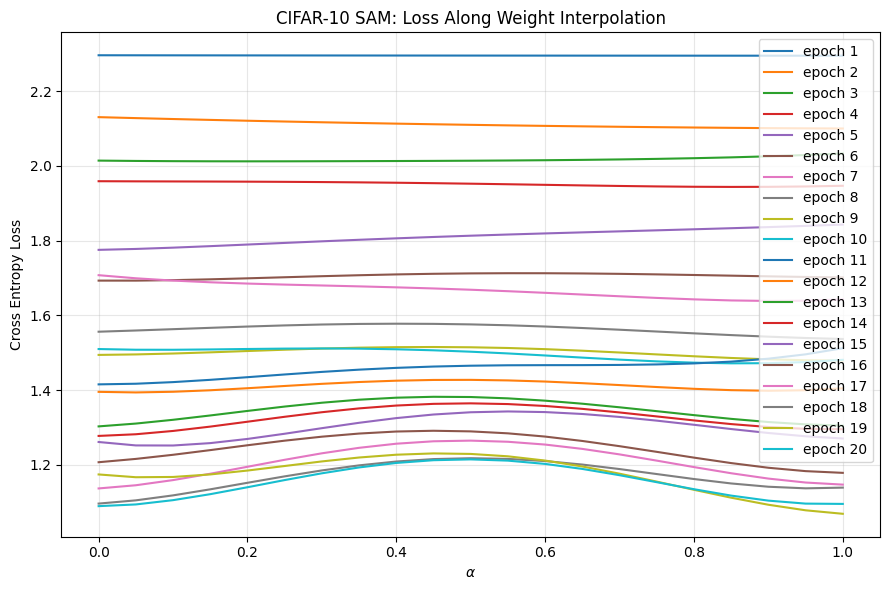

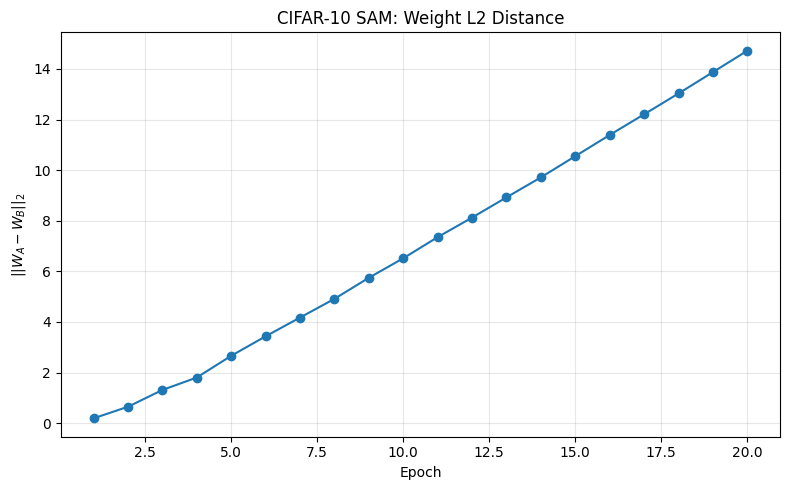

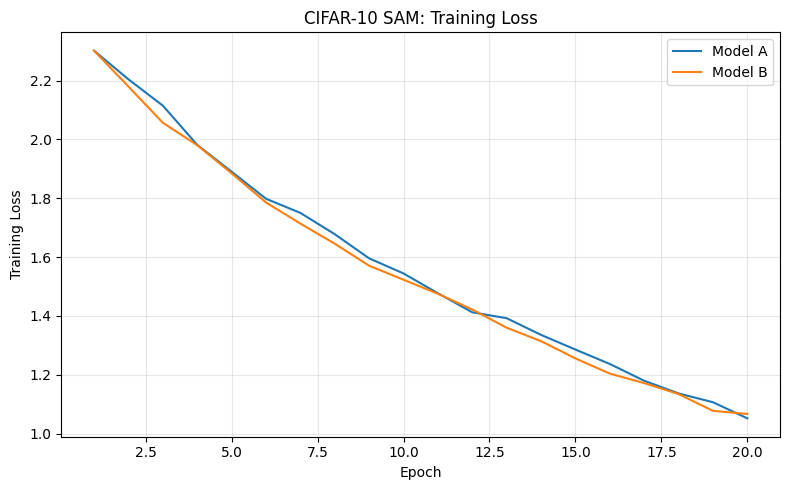


Final SAM interpolation loss
alpha=0.00 | loss=1.089178
alpha=0.05 | loss=1.093770
alpha=0.10 | loss=1.105213
alpha=0.15 | loss=1.121226
alpha=0.20 | loss=1.139783
alpha=0.25 | loss=1.158980
alpha=0.30 | loss=1.177092
alpha=0.35 | loss=1.192791
alpha=0.40 | loss=1.204795
alpha=0.45 | loss=1.212149
alpha=0.50 | loss=1.214353
alpha=0.55 | loss=1.211013
alpha=0.60 | loss=1.202242
alpha=0.65 | loss=1.188800
alpha=0.70 | loss=1.171993
alpha=0.75 | loss=1.153317
alpha=0.80 | loss=1.134522
alpha=0.85 | loss=1.117409
alpha=0.90 | loss=1.103954
alpha=0.95 | loss=1.095973
alpha=1.00 | loss=1.095178

Final weight L2 distance: 14.721990


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from datasets import load_dataset


# ============================================================
# 1. Config
# ============================================================
SEED = 42

EPOCHS = 20
BATCH_SIZE = 256

# SAM hyperparameters
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
RHO = 0.05

N_TRAIN_PER_MODEL = 25_000
N_EVAL = 1_000

N_ALPHA = 21

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. Load CIFAR-10 from Hugging Face
# ============================================================
dataset = load_dataset(
    "uoft-cs/cifar10",
    "plain_text"
)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)


# ============================================================
# 3. HF dataset -> GPU tensor
# ============================================================
def dataset_to_tensor(ds):

    images = []
    labels = []

    for sample in ds:

        # PIL -> numpy -> torch
        x = torch.from_numpy(
            np.array(sample["img"])
        )

        # [H, W, C] -> [C, H, W]
        x = x.permute(2, 0, 1)

        images.append(x)
        labels.append(sample["label"])

    X = torch.stack(images).float() / 255.0
    Y = torch.tensor(
        labels,
        dtype=torch.long
    )

    return X, Y


print("Converting train set...")

X_cpu, Y_cpu = dataset_to_tensor(
    train_dataset
)

# 전체 train set GPU
X_all = X_cpu.to(device)
Y_all = Y_cpu.to(device)

del X_cpu
del Y_cpu

print("Train:", X_all.shape)


# ============================================================
# 4. Split
#
# 25k -> Model A
# 25k -> Model B
# ============================================================
g = torch.Generator(device="cpu")
g.manual_seed(SEED)

perm = torch.randperm(
    len(X_all),
    generator=g
)

idx_A = perm[
    :N_TRAIN_PER_MODEL
]

idx_B = perm[
    N_TRAIN_PER_MODEL:
    2 * N_TRAIN_PER_MODEL
]

X_A = X_all[idx_A]
Y_A = Y_all[idx_A]

X_B = X_all[idx_B]
Y_B = Y_all[idx_B]


# ============================================================
# 5. Test set
#
# interpolation evaluation = 1000 samples
# ============================================================
print("Converting test set...")

X_test_cpu, Y_test_cpu = dataset_to_tensor(
    test_dataset
)

X_eval = X_test_cpu[:N_EVAL].to(device)
Y_eval = Y_test_cpu[:N_EVAL].to(device)

del X_test_cpu
del Y_test_cpu

print()
print("Model A:", X_A.shape)
print("Model B:", X_B.shape)
print("Eval   :", X_eval.shape)


# ============================================================
# 6. CIFAR-10 CNN
# ============================================================
class CIFARNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # 32 x 32
            nn.Conv2d(
                3,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),       # 16 x 16


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),       # 8 x 8


            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Linear(
            256,
            10
        )


    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        return self.classifier(x)


# ============================================================
# 7. SAM Optimizer
# ============================================================
class SAM(torch.optim.Optimizer):

    def __init__(
        self,
        params,
        base_optimizer,
        rho=0.05,
        adaptive=False,
        **kwargs
    ):

        if rho < 0.0:
            raise ValueError(
                "rho should be non-negative"
            )

        defaults = dict(
            rho=rho,
            adaptive=adaptive,
            **kwargs
        )

        super().__init__(
            params,
            defaults
        )

        self.base_optimizer = base_optimizer(
            self.param_groups,
            **kwargs
        )

        self.param_groups = (
            self.base_optimizer.param_groups
        )


    @torch.no_grad()
    def first_step(
        self,
        zero_grad=False
    ):

        grad_norm = self._grad_norm()

        scale = (
            self.param_groups[0]["rho"]
            / (grad_norm + 1e-12)
        )

        for group in self.param_groups:

            for p in group["params"]:

                if p.grad is None:
                    continue

                e_w = (
                    torch.pow(p, 2)
                    if group["adaptive"]
                    else 1.0
                ) * p.grad * scale.to(
                    p
                )

                p.add_(e_w)

                self.state[p]["e_w"] = e_w

        if zero_grad:
            self.zero_grad()


    @torch.no_grad()
    def second_step(
        self,
        zero_grad=False
    ):

        for group in self.param_groups:

            for p in group["params"]:

                if p.grad is None:
                    continue

                e_w = self.state[p].pop(
                    "e_w"
                )

                p.sub_(e_w)

        self.base_optimizer.step()

        if zero_grad:
            self.zero_grad()


    def _grad_norm(self):

        shared_device = self.param_groups[
            0
        ]["params"][0].device

        norms = []

        for group in self.param_groups:

            for p in group["params"]:

                if p.grad is None:
                    continue

                if group["adaptive"]:

                    grad = (
                        torch.abs(p)
                        * p.grad
                    )

                else:

                    grad = p.grad

                norms.append(
                    torch.norm(
                        grad,
                        p=2
                    ).to(shared_device)
                )

        if len(norms) == 0:
            return torch.tensor(
                0.0,
                device=shared_device
            )

        return torch.norm(
            torch.stack(norms),
            p=2
        )


    def step(self, closure=None):
        raise NotImplementedError(
            "Use first_step() and second_step()."
        )


# ============================================================
# 8. Same initialization
# ============================================================
torch.manual_seed(SEED)

model_A = CIFARNet().to(device)

model_B = CIFARNet().to(device)

model_B.load_state_dict(
    model_A.state_dict()
)


# ============================================================
# 9. SAM optimizers
# ============================================================
optimizer_A = SAM(
    model_A.parameters(),
    torch.optim.SGD,
    rho=RHO,
    adaptive=False,
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

optimizer_B = SAM(
    model_B.parameters(),
    torch.optim.SGD,
    rho=RHO,
    adaptive=False,
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 10. Weight L2 distance
# ============================================================
@torch.no_grad()
def weight_l2_distance(
    model1,
    model2
):

    sq_sum = torch.zeros(
        (),
        device=device
    )

    for p1, p2 in zip(
        model1.parameters(),
        model2.parameters()
    ):

        sq_sum += torch.sum(
            (p1 - p2) ** 2
        )

    return torch.sqrt(
        sq_sum
    )


# ============================================================
# 11. SAM training step
# ============================================================
def sam_train_step(
    model,
    optimizer,
    xb,
    yb
):

    # --------------------------------------------------------
    # First forward-backward
    # --------------------------------------------------------
    optimizer.zero_grad(
        set_to_none=True
    )

    logits = model(xb)

    loss = F.cross_entropy(
        logits,
        yb
    )

    loss.backward()

    # --------------------------------------------------------
    # Move to local sharpness-maximizing point
    # --------------------------------------------------------
    optimizer.first_step(
        zero_grad=True
    )


    # --------------------------------------------------------
    # Second forward-backward
    # --------------------------------------------------------
    logits_perturbed = model(xb)

    loss_perturbed = F.cross_entropy(
        logits_perturbed,
        yb
    )

    loss_perturbed.backward()


    # --------------------------------------------------------
    # Return to original weights + update
    # --------------------------------------------------------
    optimizer.second_step(
        zero_grad=True
    )

    return loss.item()


# ============================================================
# 12. Interpolation loss
# ============================================================
@torch.no_grad()
def interpolation_losses(
    model_A,
    model_B,
    X,
    Y,
    alphas
):

    model_A.eval()
    model_B.eval()

    params_A = [
        p.detach()
        for p in model_A.parameters()
    ]

    params_B = [
        p.detach()
        for p in model_B.parameters()
    ]

    losses = []

    for alpha in alphas:

        model_interp = CIFARNet().to(
            device
        )

        for p_interp, p_A, p_B in zip(
            model_interp.parameters(),
            params_A,
            params_B
        ):

            p_interp.copy_(
                (1.0 - alpha) * p_A
                + alpha * p_B
            )

        logits = model_interp(X)

        loss = F.cross_entropy(
            logits,
            Y
        )

        losses.append(
            loss.item()
        )

        del model_interp

    return losses


# ============================================================
# 13. Alpha
# ============================================================
alphas = torch.linspace(
    0.0,
    1.0,
    N_ALPHA,
    device=device
)


# ============================================================
# 14. Training
# ============================================================
interp_history = []
distance_history = []

loss_A_history = []
loss_B_history = []


for epoch in range(
    1,
    EPOCHS + 1
):

    model_A.train()
    model_B.train()


    # ========================================================
    # Model A
    # ========================================================
    perm_A = torch.randperm(
        N_TRAIN_PER_MODEL,
        device=device
    )

    total_loss_A = 0.0
    n_A = 0

    for start in range(
        0,
        N_TRAIN_PER_MODEL,
        BATCH_SIZE
    ):

        batch_idx = perm_A[
            start:
            start + BATCH_SIZE
        ]

        xb = X_A[batch_idx]
        yb = Y_A[batch_idx]

        loss = sam_train_step(
            model_A,
            optimizer_A,
            xb,
            yb
        )

        total_loss_A += (
            loss * len(batch_idx)
        )

        n_A += len(batch_idx)


    # ========================================================
    # Model B
    # ========================================================
    perm_B = torch.randperm(
        N_TRAIN_PER_MODEL,
        device=device
    )

    total_loss_B = 0.0
    n_B = 0

    for start in range(
        0,
        N_TRAIN_PER_MODEL,
        BATCH_SIZE
    ):

        batch_idx = perm_B[
            start:
            start + BATCH_SIZE
        ]

        xb = X_B[batch_idx]
        yb = Y_B[batch_idx]

        loss = sam_train_step(
            model_B,
            optimizer_B,
            xb,
            yb
        )

        total_loss_B += (
            loss * len(batch_idx)
        )

        n_B += len(batch_idx)


    avg_loss_A = (
        total_loss_A / n_A
    )

    avg_loss_B = (
        total_loss_B / n_B
    )

    loss_A_history.append(
        avg_loss_A
    )

    loss_B_history.append(
        avg_loss_B
    )


    # ========================================================
    # Weight L2
    # ========================================================
    distance = weight_l2_distance(
        model_A,
        model_B
    ).item()

    distance_history.append(
        distance
    )


    # ========================================================
    # Interpolation loss
    # ========================================================
    losses = interpolation_losses(
        model_A,
        model_B,
        X_eval,
        Y_eval,
        alphas
    )

    interp_history.append(
        losses
    )


    print(
        f"Epoch {epoch:3d} | "
        f"A loss: {avg_loss_A:.4f} | "
        f"B loss: {avg_loss_B:.4f} | "
        f"L2: {distance:.4f}"
    )


# ============================================================
# 15. Convert history
# ============================================================
interp_history = torch.tensor(
    interp_history
)

alphas_cpu = (
    alphas.cpu().numpy()
)


# ============================================================
# 16. Interpolation curves
# ============================================================
plt.figure(
    figsize=(9, 6)
)

for epoch in range(EPOCHS):

    plt.plot(
        alphas_cpu,
        interp_history[epoch].numpy(),
        label=f"epoch {epoch + 1}"
    )

plt.xlabel(
    r"$\alpha$"
)

plt.ylabel(
    "Cross Entropy Loss"
)

plt.title(
    "CIFAR-10 SAM: Loss Along Weight Interpolation"
)

plt.grid(
    True,
    alpha=0.3
)

if EPOCHS <= 20:
    plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 17. Weight L2 distance
# ============================================================
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    distance_history,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    r"$||W_A-W_B||_2$"
)

plt.title(
    "CIFAR-10 SAM: Weight L2 Distance"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 18. Training loss
# ============================================================
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    loss_A_history,
    label="Model A"
)

plt.plot(
    range(1, EPOCHS + 1),
    loss_B_history,
    label="Model B"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "CIFAR-10 SAM: Training Loss"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 19. Final interpolation result
# ============================================================
print()
print("=" * 60)
print("Final SAM interpolation loss")
print("=" * 60)

for alpha, loss in zip(
    alphas_cpu,
    interp_history[-1].numpy()
):

    print(
        f"alpha={alpha:.2f} | "
        f"loss={loss:.6f}"
    )

print()
print(
    f"Final weight L2 distance: "
    f"{distance_history[-1]:.6f}"
)

device: cuda
Dataset({
    features: ['img', 'label'],
    num_rows: 50000
})
Dataset({
    features: ['img', 'label'],
    num_rows: 10000
})
Converting train set...
Train: torch.Size([50000, 3, 32, 32])
Converting test set...

Model A: torch.Size([25000, 3, 32, 32])
Model B: torch.Size([25000, 3, 32, 32])
Eval   : torch.Size([1000, 3, 32, 32])
Epoch   1 | A loss: 2.1941 | B loss: 2.1619 | L2: 6.8711
Epoch   2 | A loss: 2.0703 | B loss: 2.0193 | L2: 8.8617
Epoch   3 | A loss: 1.9368 | B loss: 1.8848 | L2: 10.5476
Epoch   4 | A loss: 1.7870 | B loss: 1.7690 | L2: 12.1094
Epoch   5 | A loss: 1.6991 | B loss: 1.6869 | L2: 13.4927
Epoch   6 | A loss: 1.6356 | B loss: 1.6133 | L2: 14.8516
Epoch   7 | A loss: 1.5564 | B loss: 1.5393 | L2: 16.1449
Epoch   8 | A loss: 1.4948 | B loss: 1.4798 | L2: 17.3837
Epoch   9 | A loss: 1.4292 | B loss: 1.4293 | L2: 18.4850
Epoch  10 | A loss: 1.3664 | B loss: 1.3721 | L2: 19.3729
Epoch  11 | A loss: 1.3212 | B loss: 1.3160 | L2: 20.1939
Epoch  12 | A lo

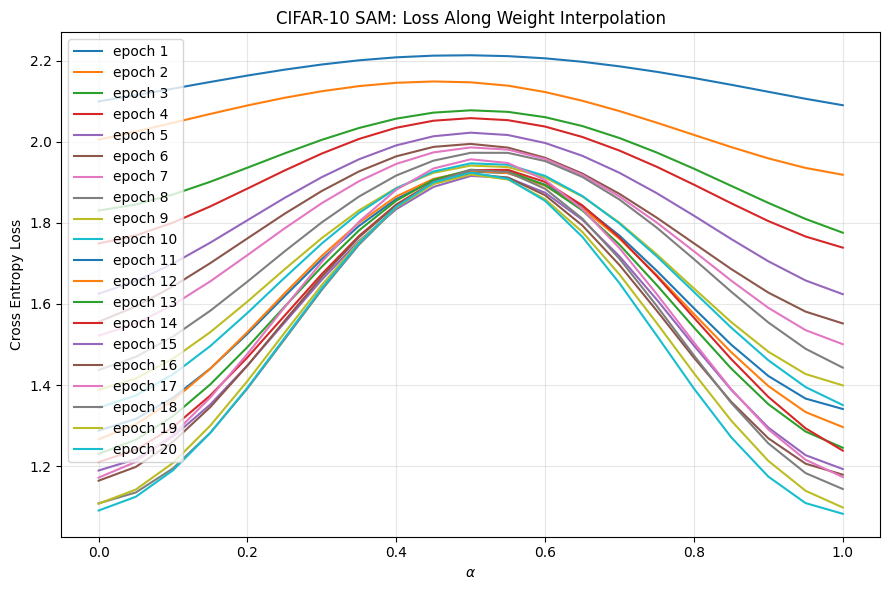

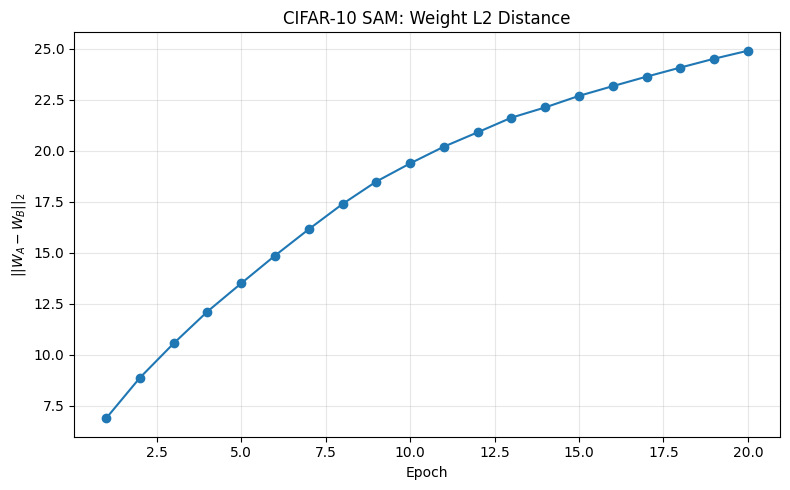

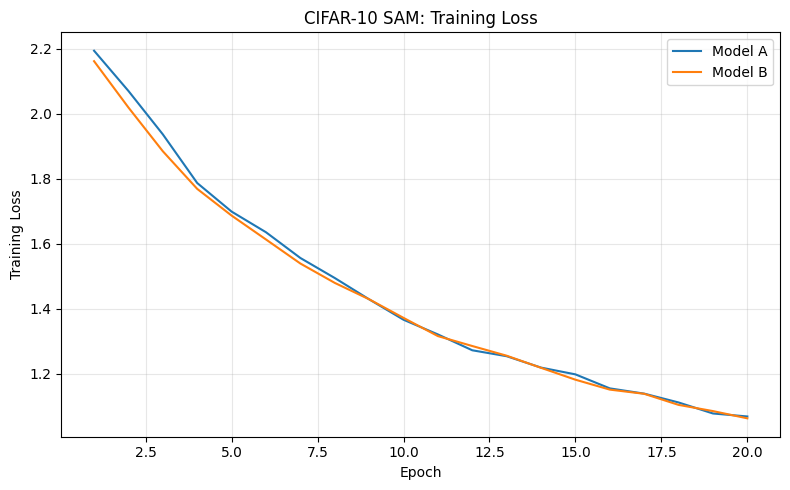


Final SAM interpolation loss
alpha=0.00 | loss=1.090466
alpha=0.05 | loss=1.124474
alpha=0.10 | loss=1.189743
alpha=0.15 | loss=1.281688
alpha=0.20 | loss=1.393691
alpha=0.25 | loss=1.516403
alpha=0.30 | loss=1.638824
alpha=0.35 | loss=1.750056
alpha=0.40 | loss=1.839842
alpha=0.45 | loss=1.899934
alpha=0.50 | loss=1.924030
alpha=0.55 | loss=1.908762
alpha=0.60 | loss=1.854351
alpha=0.65 | loss=1.765641
alpha=0.70 | loss=1.651120
alpha=0.75 | loss=1.522138
alpha=0.80 | loss=1.391254
alpha=0.85 | loss=1.271286
alpha=0.90 | loss=1.174032
alpha=0.95 | loss=1.108819
alpha=1.00 | loss=1.082432

Final weight L2 distance: 24.899494


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from datasets import load_dataset


# ============================================================
# 1. Config
# ============================================================
SEED = 42

EPOCHS = 20
BATCH_SIZE = 256

# SAM hyperparameters
LR = 1e-3
WEIGHT_DECAY = 5e-4
RHO = 0.05

N_TRAIN_PER_MODEL = 25_000
N_EVAL = 1_000

N_ALPHA = 21

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. Load CIFAR-10 from Hugging Face
# ============================================================
dataset = load_dataset(
    "uoft-cs/cifar10",
    "plain_text"
)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)


# ============================================================
# 3. HF dataset -> GPU tensor
# ============================================================
def dataset_to_tensor(ds):

    images = []
    labels = []

    for sample in ds:

        # PIL -> numpy -> torch
        x = torch.from_numpy(
            np.array(sample["img"])
        )

        # [H, W, C] -> [C, H, W]
        x = x.permute(2, 0, 1)

        images.append(x)
        labels.append(sample["label"])

    X = torch.stack(images).float() / 255.0
    Y = torch.tensor(
        labels,
        dtype=torch.long
    )

    return X, Y


print("Converting train set...")

X_cpu, Y_cpu = dataset_to_tensor(
    train_dataset
)

# 전체 train set GPU
X_all = X_cpu.to(device)
Y_all = Y_cpu.to(device)

del X_cpu
del Y_cpu

print("Train:", X_all.shape)


# ============================================================
# 4. Split
#
# 25k -> Model A
# 25k -> Model B
# ============================================================
g = torch.Generator(device="cpu")
g.manual_seed(SEED)

perm = torch.randperm(
    len(X_all),
    generator=g
)

idx_A = perm[
    :N_TRAIN_PER_MODEL
]

idx_B = perm[
    N_TRAIN_PER_MODEL:
    2 * N_TRAIN_PER_MODEL
]

X_A = X_all[idx_A]
Y_A = Y_all[idx_A]

X_B = X_all[idx_B]
Y_B = Y_all[idx_B]


# ============================================================
# 5. Test set
#
# interpolation evaluation = 1000 samples
# ============================================================
print("Converting test set...")

X_test_cpu, Y_test_cpu = dataset_to_tensor(
    test_dataset
)

X_eval = X_test_cpu[:N_EVAL].to(device)
Y_eval = Y_test_cpu[:N_EVAL].to(device)

del X_test_cpu
del Y_test_cpu

print()
print("Model A:", X_A.shape)
print("Model B:", X_B.shape)
print("Eval   :", X_eval.shape)


# ============================================================
# 6. CIFAR-10 CNN
# ============================================================
class CIFARNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # 32 x 32
            nn.Conv2d(
                3,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),       # 16 x 16


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),       # 8 x 8


            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Linear(
            256,
            10
        )


    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        return self.classifier(x)


# ============================================================
# 7. SAM Optimizer
# ============================================================
class SAM(torch.optim.Optimizer):

    def __init__(
        self,
        params,
        base_optimizer,
        rho=0.05,
        adaptive=False,
        **kwargs
    ):

        if rho < 0.0:
            raise ValueError(
                "rho should be non-negative"
            )

        defaults = dict(
            rho=rho,
            adaptive=adaptive,
            **kwargs
        )

        super().__init__(
            params,
            defaults
        )

        self.base_optimizer = base_optimizer(
            self.param_groups,
            **kwargs
        )

        self.param_groups = (
            self.base_optimizer.param_groups
        )


    @torch.no_grad()
    def first_step(
        self,
        zero_grad=False
    ):

        grad_norm = self._grad_norm()

        scale = (
            self.param_groups[0]["rho"]
            / (grad_norm + 1e-12)
        )

        for group in self.param_groups:

            for p in group["params"]:

                if p.grad is None:
                    continue

                e_w = (
                    torch.pow(p, 2)
                    if group["adaptive"]
                    else 1.0
                ) * p.grad * scale.to(
                    p
                )

                p.add_(e_w)

                self.state[p]["e_w"] = e_w

        if zero_grad:
            self.zero_grad()


    @torch.no_grad()
    def second_step(
        self,
        zero_grad=False
    ):

        for group in self.param_groups:

            for p in group["params"]:

                if p.grad is None:
                    continue

                e_w = self.state[p].pop(
                    "e_w"
                )

                p.sub_(e_w)

        self.base_optimizer.step()

        if zero_grad:
            self.zero_grad()


    def _grad_norm(self):

        shared_device = self.param_groups[
            0
        ]["params"][0].device

        norms = []

        for group in self.param_groups:

            for p in group["params"]:

                if p.grad is None:
                    continue

                if group["adaptive"]:

                    grad = (
                        torch.abs(p)
                        * p.grad
                    )

                else:

                    grad = p.grad

                norms.append(
                    torch.norm(
                        grad,
                        p=2
                    ).to(shared_device)
                )

        if len(norms) == 0:
            return torch.tensor(
                0.0,
                device=shared_device
            )

        return torch.norm(
            torch.stack(norms),
            p=2
        )


    def step(self, closure=None):
        raise NotImplementedError(
            "Use first_step() and second_step()."
        )


# ============================================================
# 8. Same initialization
# ============================================================
torch.manual_seed(SEED)

model_A = CIFARNet().to(device)

model_B = CIFARNet().to(device)

model_B.load_state_dict(
    model_A.state_dict()
)


# ============================================================
# 9. SAM optimizers
# ============================================================
optimizer_A = SAM(
    model_A.parameters(),
    torch.optim.Adam,
    rho=RHO,
    adaptive=False,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

optimizer_B = SAM(
    model_B.parameters(),
    torch.optim.Adam,
    rho=RHO,
    adaptive=False,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 10. Weight L2 distance
# ============================================================
@torch.no_grad()
def weight_l2_distance(
    model1,
    model2
):

    sq_sum = torch.zeros(
        (),
        device=device
    )

    for p1, p2 in zip(
        model1.parameters(),
        model2.parameters()
    ):

        sq_sum += torch.sum(
            (p1 - p2) ** 2
        )

    return torch.sqrt(
        sq_sum
    )


# ============================================================
# 11. SAM training step
# ============================================================
def sam_train_step(
    model,
    optimizer,
    xb,
    yb
):

    # --------------------------------------------------------
    # First forward-backward
    # --------------------------------------------------------
    optimizer.zero_grad(
        set_to_none=True
    )

    logits = model(xb)

    loss = F.cross_entropy(
        logits,
        yb
    )

    loss.backward()

    # --------------------------------------------------------
    # Move to local sharpness-maximizing point
    # --------------------------------------------------------
    optimizer.first_step(
        zero_grad=True
    )


    # --------------------------------------------------------
    # Second forward-backward
    # --------------------------------------------------------
    logits_perturbed = model(xb)

    loss_perturbed = F.cross_entropy(
        logits_perturbed,
        yb
    )

    loss_perturbed.backward()


    # --------------------------------------------------------
    # Return to original weights + update
    # --------------------------------------------------------
    optimizer.second_step(
        zero_grad=True
    )

    return loss.item()


# ============================================================
# 12. Interpolation loss
# ============================================================
@torch.no_grad()
def interpolation_losses(
    model_A,
    model_B,
    X,
    Y,
    alphas
):

    model_A.eval()
    model_B.eval()

    params_A = [
        p.detach()
        for p in model_A.parameters()
    ]

    params_B = [
        p.detach()
        for p in model_B.parameters()
    ]

    losses = []

    for alpha in alphas:

        model_interp = CIFARNet().to(
            device
        )

        for p_interp, p_A, p_B in zip(
            model_interp.parameters(),
            params_A,
            params_B
        ):

            p_interp.copy_(
                (1.0 - alpha) * p_A
                + alpha * p_B
            )

        logits = model_interp(X)

        loss = F.cross_entropy(
            logits,
            Y
        )

        losses.append(
            loss.item()
        )

        del model_interp

    return losses


# ============================================================
# 13. Alpha
# ============================================================
alphas = torch.linspace(
    0.0,
    1.0,
    N_ALPHA,
    device=device
)


# ============================================================
# 14. Training
# ============================================================
interp_history = []
distance_history = []

loss_A_history = []
loss_B_history = []


for epoch in range(
    1,
    EPOCHS + 1
):

    model_A.train()
    model_B.train()


    # ========================================================
    # Model A
    # ========================================================
    perm_A = torch.randperm(
        N_TRAIN_PER_MODEL,
        device=device
    )

    total_loss_A = 0.0
    n_A = 0

    for start in range(
        0,
        N_TRAIN_PER_MODEL,
        BATCH_SIZE
    ):

        batch_idx = perm_A[
            start:
            start + BATCH_SIZE
        ]

        xb = X_A[batch_idx]
        yb = Y_A[batch_idx]

        loss = sam_train_step(
            model_A,
            optimizer_A,
            xb,
            yb
        )

        total_loss_A += (
            loss * len(batch_idx)
        )

        n_A += len(batch_idx)


    # ========================================================
    # Model B
    # ========================================================
    perm_B = torch.randperm(
        N_TRAIN_PER_MODEL,
        device=device
    )

    total_loss_B = 0.0
    n_B = 0

    for start in range(
        0,
        N_TRAIN_PER_MODEL,
        BATCH_SIZE
    ):

        batch_idx = perm_B[
            start:
            start + BATCH_SIZE
        ]

        xb = X_B[batch_idx]
        yb = Y_B[batch_idx]

        loss = sam_train_step(
            model_B,
            optimizer_B,
            xb,
            yb
        )

        total_loss_B += (
            loss * len(batch_idx)
        )

        n_B += len(batch_idx)


    avg_loss_A = (
        total_loss_A / n_A
    )

    avg_loss_B = (
        total_loss_B / n_B
    )

    loss_A_history.append(
        avg_loss_A
    )

    loss_B_history.append(
        avg_loss_B
    )


    # ========================================================
    # Weight L2
    # ========================================================
    distance = weight_l2_distance(
        model_A,
        model_B
    ).item()

    distance_history.append(
        distance
    )


    # ========================================================
    # Interpolation loss
    # ========================================================
    losses = interpolation_losses(
        model_A,
        model_B,
        X_eval,
        Y_eval,
        alphas
    )

    interp_history.append(
        losses
    )


    print(
        f"Epoch {epoch:3d} | "
        f"A loss: {avg_loss_A:.4f} | "
        f"B loss: {avg_loss_B:.4f} | "
        f"L2: {distance:.4f}"
    )


# ============================================================
# 15. Convert history
# ============================================================
interp_history = torch.tensor(
    interp_history
)

alphas_cpu = (
    alphas.cpu().numpy()
)


# ============================================================
# 16. Interpolation curves
# ============================================================
plt.figure(
    figsize=(9, 6)
)

for epoch in range(EPOCHS):

    plt.plot(
        alphas_cpu,
        interp_history[epoch].numpy(),
        label=f"epoch {epoch + 1}"
    )

plt.xlabel(
    r"$\alpha$"
)

plt.ylabel(
    "Cross Entropy Loss"
)

plt.title(
    "CIFAR-10 SAM: Loss Along Weight Interpolation"
)

plt.grid(
    True,
    alpha=0.3
)

if EPOCHS <= 20:
    plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 17. Weight L2 distance
# ============================================================
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    distance_history,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    r"$||W_A-W_B||_2$"
)

plt.title(
    "CIFAR-10 SAM: Weight L2 Distance"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 18. Training loss
# ============================================================
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    loss_A_history,
    label="Model A"
)

plt.plot(
    range(1, EPOCHS + 1),
    loss_B_history,
    label="Model B"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "CIFAR-10 SAM: Training Loss"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 19. Final interpolation result
# ============================================================
print()
print("=" * 60)
print("Final SAM interpolation loss")
print("=" * 60)

for alpha, loss in zip(
    alphas_cpu,
    interp_history[-1].numpy()
):

    print(
        f"alpha={alpha:.2f} | "
        f"loss={loss:.6f}"
    )

print()
print(
    f"Final weight L2 distance: "
    f"{distance_history[-1]:.6f}"
)